# SDG Project - Analisi Esplorativa del Dataset
- Caricamento del dataset
- Descrizione del dataset
- Data Cleaning (gestione dei missing values) 
- 

In [1]:
# Import delle librerie principali
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Caricamento dei dataset
# Nota: dataset.csv utilizza ';' come separatore e ',' come separatore decimale per i valori numerici
df = pd.read_csv('dataset/dataset.csv', sep=';', decimal=',')
data_desc = pd.read_csv('dataset/data_descriptions.csv', sep=';')

print("Dataset caricati con successo!")

Dataset caricati con successo!


### 1. Descrizione dataset 
Verifichiamo la dimensione complessiva del dataset (numero di righe e colonne) e analizziamo i tipi di dato (`dtypes`) associati a ciascuna colonna.
Separiamo le colonne del dataset in **categoriche** (identificate dal tipo `object`/`string` o dal prefisso `text_format` nelle descrizioni) e **numeriche**. Eseguiamo infine `.describe()` separatamente per i due gruppi.

In [2]:
from IPython.display import display
# 1. Shape del dataset (righe, colonne)
print(f"Shape del dataset: {df.shape[0]} righe, {df.shape[1]} colonne\n")

# Prime 5 righe
print("--- Prime 5 righe del dataset ---")
display(df.head())

# Tipi di dato delle colonne (dtypes)
# print("\n--- Tipi di dato (dtypes) - Prime 20 colonne ---")
# display(df.dtypes.to_frame(name='dtype').head(20))

# Elenco variabili con prefisso text_format nelle descrizioni
tf_vars = set(data_desc[data_desc['Variable'].astype(str).str.startswith('text_format')]['Variable'].astype(str).str.replace('text_format', '').str.lower())

# Classificazione colonne categoriche vs numeriche
cat_cols = [c for c in df.columns if str(df[c].dtype) in ['object', 'string', 'str'] or c.lower() in tf_vars]
num_cols = [c for c in df.columns if c not in cat_cols]

print(f"Numero Colonne Categoriche: {len(cat_cols)}")
# print(f"Colonne Categoriche: {cat_cols}\n")
print(f"Numero Colonne Numeriche: {len(num_cols)}\n")

# print("--- Describe Colonne Numeriche (Prime 10) ---")
# display(df[num_cols].describe().T.head(10))

# print("\n--- Describe Colonne Categoriche ---")
# display(df[cat_cols].describe().T)

# Numero di categorie uniche per ogni colonna categorica
cat_summary = pd.DataFrame({
    'colonna': cat_cols,
    'n_categorie': [df[c].nunique(dropna=True) for c in cat_cols],
    'n_missing': [df[c].isna().sum() for c in cat_cols]
}).sort_values('n_categorie', ascending=False).reset_index(drop=True)

print(f"--- Numero di categorie per ciascuna delle {len(cat_cols)} colonne categoriche ---")
display(cat_summary)

for c in cat_cols:
    n = df[c].nunique(dropna=True)
    if n <= 15:  # mostra i valori solo se sono "gestibili"
        print(f"{c} ({n} categorie): {sorted(df[c].dropna().unique().tolist())}")
    else:
        print(f"{c} ({n} categorie): troppe per l'elenco, es. {df[c].dropna().unique()[:5].tolist()}...")

Shape del dataset: 100000 righe, 100 colonne

--- Prime 5 righe del dataset ---


,rev_Mean,mou_Mean,totmrc_Mean,da_Mean,ovrmou_Mean,ovrrev_Mean,vceovr_Mean,datovr_Mean,roam_Mean,change_mou,...,forgntvl,ethnic,kid0_2,kid3_5,kid6_10,kid11_15,kid16_17,creditcd,eqpdays,Customer_ID
0,23.9975,219.25,22.500,0.2475,0.00,0.0,0.0,0.0,0.0,-157.25,...,0.0,N,U,U,U,U,U,Y,361.0,1000001
1,57.4925,482.75,37.425,0.2475,22.75,9.1,9.1,0.0,0.0,532.25,...,0.0,Z,U,U,U,U,U,Y,240.0,1000002
2,16.9900,10.25,16.990,0.0000,0.00,0.0,0.0,0.0,0.0,-4.25,...,0.0,N,U,Y,U,U,U,Y,1504.0,1000003
3,38.0000,7.50,38.000,0.0000,0.00,0.0,0.0,0.0,0.0,-1.50,...,0.0,U,Y,U,U,U,U,Y,1812.0,1000004
4,55.2300,570.50,71.980,0.0000,0.00,0.0,0.0,0.0,0.0,38.50,...,0.0,I,U,U,U,U,U,Y,434.0,1000005


Numero Colonne Categoriche: 21
Numero Colonne Numeriche: 79

--- Numero di categorie per ciascuna delle 21 colonne categoriche ---


,colonna,n_categorie,n_missing
0,crclscod,54,0
1,area,19,40
2,ethnic,17,1732
3,dwllsize,15,38308
4,HHstatin,6,37923
5,marital,5,1732
6,prizm_social_one,5,7388
7,dualband,4,1
8,new_cell,3,0
9,hnd_webcap,3,10189


new_cell (3 categorie): ['N', 'U', 'Y']
crclscod (54 categorie): troppe per l'elenco, es. ['A', 'EA', 'C', 'B', 'BA']...
asl_flag (2 categorie): ['N', 'Y']
prizm_social_one (5 categorie): ['C', 'R', 'S', 'T', 'U']
area (19 categorie): troppe per l'elenco, es. ['NORTHWEST/ROCKY MOUNTAIN AREA', 'CHICAGO AREA', 'GREAT LAKES AREA', 'NEW ENGLAND AREA', 'DALLAS AREA']...
dualband (4 categorie): ['N', 'T', 'U', 'Y']
refurb_new (2 categorie): ['N', 'R']
hnd_webcap (3 categorie): ['UNKW', 'WC', 'WCMB']
ownrent (2 categorie): ['O', 'R']
dwlltype (2 categorie): ['M', 'S']
marital (5 categorie): ['A', 'B', 'M', 'S', 'U']
infobase (2 categorie): ['M', 'N']
HHstatin (6 categorie): ['A', 'B', 'C', 'G', 'H', 'I']
dwllsize (15 categorie): ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O']
ethnic (17 categorie): troppe per l'elenco, es. ['N', 'Z', 'U', 'I', 'S']...
kid0_2 (2 categorie): ['U', 'Y']
kid3_5 (2 categorie): ['U', 'Y']
kid6_10 (2 categorie): ['U', 'Y']
kid11_15 (2 cat

### 2. Distribuzione della Colonna Target "churn"
Analizziamo la distribuzione della variabile target `churn` sia in termini di frequenza assoluta che percentuale, per verificare il bilanciamento delle classi (presenza di eventuale class imbalance).
Classe 1 clienti abbandonano il servizio, classe 0 no.

In [3]:
# Conteggio assoluto e percentuale della variabile target churn
churn_counts = df['churn'].value_counts(dropna=False)
churn_pct = df['churn'].value_counts(normalize=True, dropna=False) * 100

churn_dist = pd.DataFrame({
    'Conteggio Assoluto': churn_counts,
    'Percentuale (%)': churn_pct.round(2)
})

display(churn_dist)

# Valutazione del bilanciamento
pct_0, pct_1 = churn_pct.get(0, 0), churn_pct.get(1, 0)
print(f"\nDistribuzione target: Classe 0 = {pct_0:.2f}%, Classe 1 = {pct_1:.2f}%")
if abs(pct_0 - pct_1) < 10:
    print("Esito: La variabile target 'churn' risulta perfettamente bilanciata (~50% vs ~50%).")
else:
    print("Esito: La variabile target 'churn' risulta sbilanciata.")

,Conteggio Assoluto,Percentuale (%)
churn,,
0,50438,50.44
1,49562,49.56



Distribuzione target: Classe 0 = 50.44%, Classe 1 = 49.56%
Esito: La variabile target 'churn' risulta perfettamente bilanciata (~50% vs ~50%).


### 3. Splitto il dataset in train e test
Lo suddivido in modo randomico 70% train e 30% test. 
La popolazione è rappresentata in entrambi i dataset? Dovrei suddividere bilanciando la classe churn nei due dataset?

In [4]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline

# Creo una copia di df da usare per lo split
df_clean = df.copy()

# Controllo il formato delle colonne 
print(df_clean.dtypes)

#Imposto Customer_ID come colonna indice 
df_clean = df_clean.set_index('Customer_ID')

# Split in train e test set
X = df_clean.drop(columns=['churn'])  
y = df_clean['churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# Numero di righe in train e test set
print(f"Dimensione training set: {X_train.shape[0]} righe")
print(f"Dimensione test set: {X_test.shape[0]} righe")

# Verifica che la somma corrisponda al dataset originale
print(f"Somma train + test: {X_train.shape[0] + X_test.shape[0]}")
print(f"Dimensione dataset originale (X): {X.shape[0]} righe")
print(f"Corrispondenza: {X_train.shape[0] + X_test.shape[0] == X.shape[0]}")

# Controllo anche sulle y (dovrebbero combaciare)
print(f"\nDimensione y_train: {y_train.shape[0]}")
print(f"Dimensione y_test: {y_test.shape[0]}")



rev_Mean       float64
mou_Mean       float64
totmrc_Mean    float64
da_Mean        float64
ovrmou_Mean    float64
                ...   
kid11_15           str
kid16_17           str
creditcd           str
eqpdays        float64
Customer_ID      int64
Length: 100, dtype: object
Dimensione training set: 70000 righe
Dimensione test set: 30000 righe
Somma train + test: 100000
Dimensione dataset originale (X): 100000 righe
Corrispondenza: True

Dimensione y_train: 70000
Dimensione y_test: 30000


### 4. Analisi dei Missing Values (MVs)
Calcoliamo il numero di missing values (`null/NaN`) per ciascuna colonna.
L'output è ordinato in modo decrescente e include esclusivamente le colonne con un numero di valori mancanti superiore a zero (`missing > 0`).

Impostiamo una soglia del 30% e attuiamo la strategia di gestione dei MVs:

**Numeriche**
MVs > 30%: Rimozione colonna
MVs < 30%: Imputazione con mediana

**Categoriche**
Categoria ‘MISSING’


In [5]:
import pandas as pd
import numpy as np
from sklearn.base import BaseEstimator, TransformerMixin

class MissingValueHandler(BaseEstimator, TransformerMixin):
    """
    Gestisce i missing values secondo la strategia:
    - Colonne numeriche/categoriche con MVs > 30%): rimosse
    - Colonne numeriche con MVs <= soglia: imputate con la mediana (calcolata sul train)
    - Colonne categoriche con MVs <= soglia: imputate con 'MISSING'
    """
    
    def __init__(self, threshold=30):
        self.threshold = threshold

    def fit(self, X, y=None):
        X = X.copy()
        
        missing_pct = (X.isnull().sum() / len(X)) * 100
        num_cols = X.select_dtypes(include=[np.number]).columns
        cat_cols = X.select_dtypes(include=['object']).columns

        num_gt30 = missing_pct[(missing_pct.index.isin(num_cols)) & (missing_pct > self.threshold)]
        cat_gt30 = missing_pct[(missing_pct.index.isin(cat_cols)) & (missing_pct > self.threshold)]

        # Colonne da eliminare (appreso SOLO dal train)
        self.cols_to_drop_ = num_gt30.index.tolist() + cat_gt30.index.tolist()

        # Mediane per le colonne numeriche rimanenti (appreso SOLO dal train)
        remaining_num_cols = [c for c in num_cols if c not in self.cols_to_drop_]
        self.medians_ = {col: X[col].median() for col in remaining_num_cols}

        # Colonne categoriche rimanenti (per riferimento)
        self.remaining_cat_cols_ = [c for c in cat_cols if c not in self.cols_to_drop_]

        return self

    def transform(self, X):
        X = X.copy()
        
        # Drop delle colonne (stesse decise in fit)
        X = X.drop(columns=[c for c in self.cols_to_drop_ if c in X.columns])

        # Imputazione numeriche con mediana del train
        for col, median_value in self.medians_.items():
            if col in X.columns:
                X[col] = X[col].fillna(median_value)

        # Imputazione categoriche con 'MISSING'
        for col in self.remaining_cat_cols_:
            if col in X.columns:
                X[col] = X[col].fillna('MISSING')

        return X


handler = MissingValueHandler(threshold=30)
X_train_clean = handler.fit_transform(X_train)   # fit + transform sul train
X_test_clean = handler.transform(X_test)          # solo transform sul test

/var/folders/4h/5qwyggjn6mxby9hbd4nr62th0000gn/T/ipykernel_5747/1086011775.py:21: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = X.select_dtypes(include=['object']).columns


### 5. Uniformazione dati da dare in input al Random Forest 
Le categoriche devono essere trasformate in numeriche


In [6]:
#Individuo le colonne categoriche rimaste
cat_features = X_train_clean.select_dtypes(include=['object']).columns.tolist()
num_features = X_train_clean.select_dtypes(include=[np.number]).columns.tolist()

print(f"Colonne categoriche rimaste: len{cat_features}")
print(f"Colonne numeriche rimaste: len{num_features}")

# Encoding sulle colonne rimaste
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_features)
    ],
    remainder='passthrough'  # le numeriche passano invariate
)

X_train_encoded = preprocessor.fit_transform(X_train_clean)  # fit + transform sul train
X_test_encoded = preprocessor.transform(X_test_clean)         # solo transform sul test

/var/folders/4h/5qwyggjn6mxby9hbd4nr62th0000gn/T/ipykernel_5747/542128104.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_features = X_train_clean.select_dtypes(include=['object']).columns.tolist()


Colonne categoriche rimaste: len['new_cell', 'crclscod', 'asl_flag', 'prizm_social_one', 'area', 'dualband', 'refurb_new', 'hnd_webcap', 'marital', 'infobase', 'ethnic', 'kid0_2', 'kid3_5', 'kid6_10', 'kid11_15', 'kid16_17', 'creditcd']
Colonne numeriche rimaste: len['rev_Mean', 'mou_Mean', 'totmrc_Mean', 'da_Mean', 'ovrmou_Mean', 'ovrrev_Mean', 'vceovr_Mean', 'datovr_Mean', 'roam_Mean', 'change_mou', 'change_rev', 'drop_vce_Mean', 'drop_dat_Mean', 'blck_vce_Mean', 'blck_dat_Mean', 'unan_vce_Mean', 'unan_dat_Mean', 'plcd_vce_Mean', 'plcd_dat_Mean', 'recv_vce_Mean', 'recv_sms_Mean', 'comp_vce_Mean', 'comp_dat_Mean', 'custcare_Mean', 'ccrndmou_Mean', 'cc_mou_Mean', 'inonemin_Mean', 'threeway_Mean', 'mou_cvce_Mean', 'mou_cdat_Mean', 'mou_rvce_Mean', 'owylis_vce_Mean', 'mouowylisv_Mean', 'iwylis_vce_Mean', 'mouiwylisv_Mean', 'peak_vce_Mean', 'peak_dat_Mean', 'mou_peav_Mean', 'mou_pead_Mean', 'opk_vce_Mean', 'opk_dat_Mean', 'mou_opkv_Mean', 'mou_opkd_Mean', 'drop_blk_Mean', 'attempt_Mean', 

### 6. Random Forest per capire la permutation importance 
Voglio capire quali variabili sono più significative per il churn e lavorare su quelle.


Accuracy su train: 1.0000
Accuracy su test: 0.6217

Numero totale di feature dopo l'encoding: 216

--- TOP 20 variabili più importanti (Permutation Importance) ---


,Feature,Importance_Mean,Importance_Std
0,remainder__eqpdays,0.015037,0.001683
1,remainder__months,0.009390,0.000875
2,remainder__change_mou,0.006867,0.000988
3,remainder__avgqty,0.003713,0.000695
4,remainder__totmrc_Mean,0.003267,0.000803
5,remainder__avgmou,0.002403,0.000825
6,remainder__mou_Mean,0.002267,0.001011
7,remainder__mou_cvce_Mean,0.002057,0.000489
8,remainder__recv_vce_Mean,0.001647,0.000552
9,cat__asl_flag_Y,0.001607,0.000456


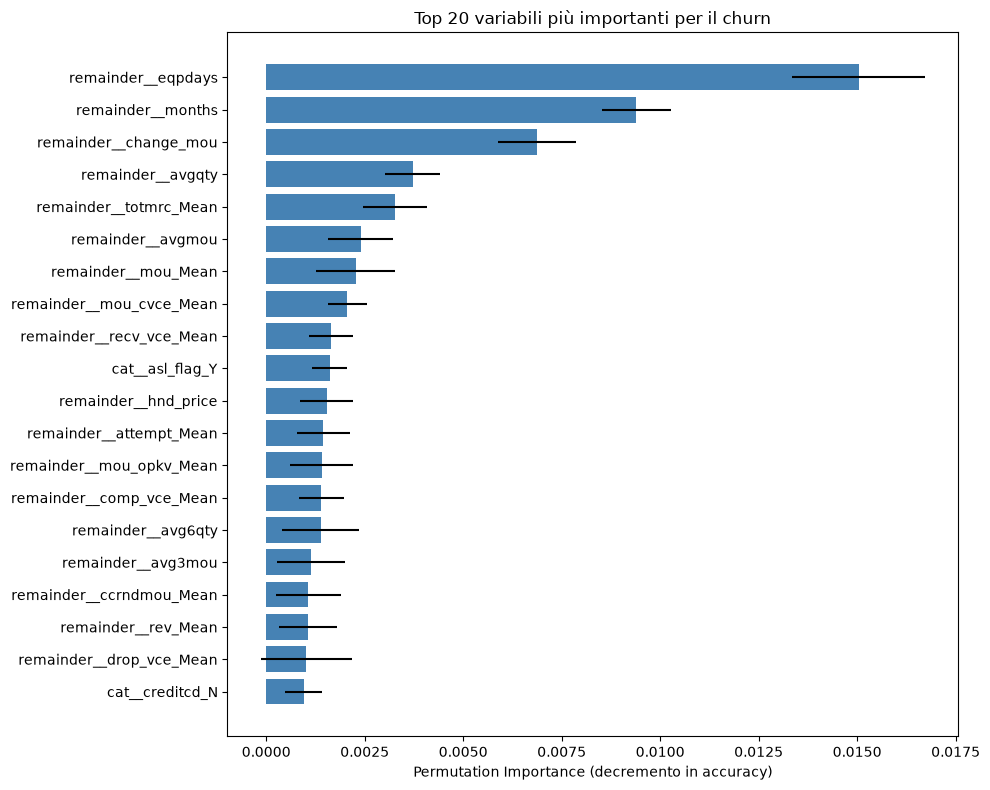

In [7]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance
import pandas as pd
import numpy as np

# --- STEP 3a: Random Forest esplorativo ---
# serve solo per capire le variabili importanti
rf_explore = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    n_jobs=1  
)

rf_explore.fit(X_train_encoded, y_train) 
# Fa sia predizione del churn sulle osservazioni del test set
# che calcola l'accuracy

print(f"Accuracy su train: {rf_explore.score(X_train_encoded, y_train):.4f}")
print(f"Accuracy su test: {rf_explore.score(X_test_encoded, y_test):.4f}")

# --- STEP 3b: Recupero i nomi delle feature dopo il OneHotEncoding ---
# Necessario perché dopo l'encoding le colonne non si chiamano più come prima
# (es. 'Region' diventa 'Region_Nord', 'Region_Sud', ecc.)
feature_names = preprocessor.get_feature_names_out()

print(f"\nNumero totale di feature dopo l'encoding: {len(feature_names)}")

# --- STEP 3c: Permutation Importance (calcolata sul TEST set) ---
# Perché sul test set? Perché misura quanto il modello si affida a una variabile
# per generalizzare su dati mai visti

perm_result = permutation_importance(
    rf_explore,
    X_test_encoded,
    y_test,
    n_repeats=10,      
    random_state=42,
    n_jobs=1
)

# --- STEP 3d: Organizzo i risultati in un DataFrame ordinato (associo nome variabile con importanza) ---
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance_Mean': perm_result.importances_mean,
    'Importance_Std': perm_result.importances_std
}).sort_values(by='Importance_Mean', ascending=False).reset_index(drop=True)

print("\n--- TOP 20 variabili più importanti (Permutation Importance) ---")
display(importance_df.head(20))

# --- STEP 3e: Visualizzazione grafica delle top variabili ---
import matplotlib.pyplot as plt

top_n = 20
top_features = importance_df.head(top_n)

plt.figure(figsize=(10, 8))
plt.barh(top_features['Feature'], top_features['Importance_Mean'], 
         xerr=top_features['Importance_Std'], color='steelblue')
plt.xlabel('Permutation Importance (decremento in accuracy)')
plt.title(f'Top {top_n} variabili più importanti per il churn')
plt.gca().invert_yaxis()  # la più importante in alto
plt.tight_layout()
plt.show()